# Understanding Karman filtering

In [24]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

For this simple example we will take an underlying true process, of a measure with some velocity and starting position 0.  
init_position = 0
inti_velocity = 1
> i.e position += velocity * time

In [25]:
steps = 100
dt = 1.0

#set up init array
true_position = np.zeros(steps)
true_velocity = np.zeros(steps)
measurements = np.zeros(steps)

true_position[0] = 0.0
true_velocity[0] = 1.0

The true velocity will update as gaussian root process / random walk with variance 0.1.

Then measurements will be taken as the true + noise of variance 15

In [26]:
process_noise_std = 0.1     # Variance in the actual underlying movement 
measurement_noise_std = 15.0 # How erratic our data feed/sensor is

In [27]:
# 3. Generate the data loop
for t in range(1, steps):
    # The true state evolves: v_t = v_{t-1} + noise, x_t = x_{t-1} + v_t * dt
    true_velocity[t] = true_velocity[t-1] + np.random.normal(0, process_noise_std)
    true_position[t] = true_position[t-1] + true_velocity[t] * dt
    
    # The measurement is simply the true position obscured by heavy noise
    measurements[t] = true_position[t] + np.random.normal(0, measurement_noise_std)

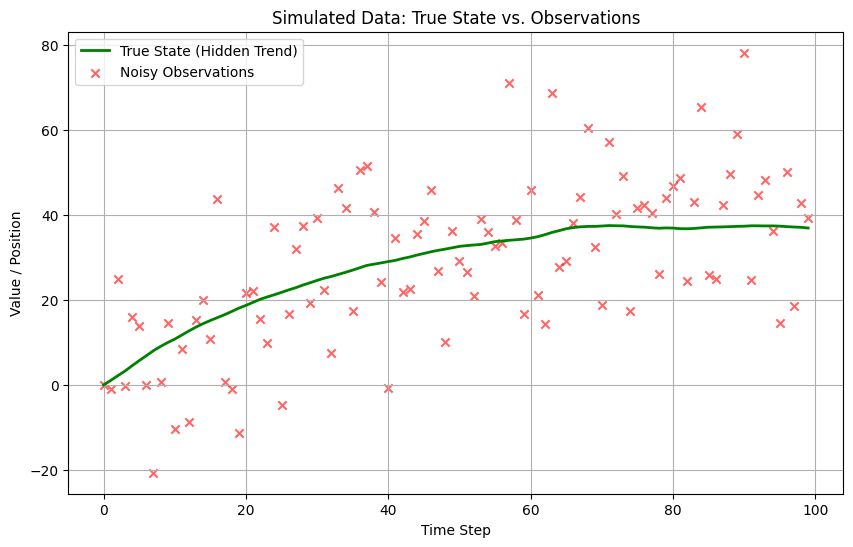

In [28]:
# 4. Visualise the starting data
plt.figure(figsize=(10, 6))
plt.plot(true_position, label='True State (Hidden Trend)', color='green', linewidth=2)
plt.scatter(range(steps), measurements, label='Noisy Observations', color='red', marker='x', alpha=0.6)
plt.title('Simulated Data: True State vs. Observations')
plt.xlabel('Time Step')
plt.ylabel('Value / Position')
plt.legend()
plt.grid(True)
plt.show()

Kalman filter is essentially a sequential Bayesian updating process.

The Predict step pushes our current belief forward in time to form a prior, and the Update step incorporates the likelihood of the new noisy measurement to calculate the posterior (our new state estimate).

 - State ($x$): We are tracking a 2D state: [position, velocity].
 - Transition ($F$): How position and velocity evolve over time ($dt$).
 - Observation ($H$): Maps our 2D state to our 1D measurement (because our sensor only reads position, not velocity).Covariances ($P, Q, R$): Our uncertainty in the initial guess, the model, and the sensor, respectively.

In standard bayes:
$$P(\text{State} \mid \text{Data}) \propto P(\text{Data} \mid \text{State}) \times P(\text{State})$$
In the context of time series, we can update the belief about the current state $x_t$ given the previous history $z_{1:t}$. 

So we condition everything on the history of previous measurements up to time $t-1$, denoted as $z_{1:t-1}$. When the new measurement $z_t$ arrives, the Bayesian update becomes:$$p(x_t \mid z_{1:t}) \propto p(z_t \mid x_t) \times p(x_t \mid z_{1:t-1})$$

### Prior 
As we have seen no data, we can represent our belief of the current state $x_t$ in the form of a multivariate Gaussian distribution.  
The prior prediction can look like:
$$x \sim \mathcal{N}(\hat{x}^-, P^-)$$
where $\hat{x}^- = [0,0]$ and $P^- = \begin{bmatrix}
1000 & 0 \\
0 & 1000
\end{bmatrix}
$
where here the $1000$ is just representing a high degree of uncertainty 

Noting we have a state that is positon and velocity, we must reduce this to just position.  
THis can be done with a state trasition matrix $F$ where as we know from before, using velocity and positon to get the new positon should be given by: $pos_t = pos_{t-1} + dt*v_t$. 
But if we have state $X$ we can use the obervation matrix $H$ to jsut get positon. 
$$
F =
\begin{bmatrix}
1 & \Delta t \\
0 & 1
\end{bmatrix},
\qquad
H =
\begin{bmatrix}
1 & 0
\end{bmatrix}.
$$

$$
\mathbf{x}_k =
\begin{bmatrix}
\text{position}_k \\
\text{velocity}_k
\end{bmatrix},
$$

where the state evolves according to

$$
\mathbf{x}_k
=
F \mathbf{x}_{k-1}
=
\begin{bmatrix}
1 & \Delta t \\
0 & 1
\end{bmatrix}
\mathbf{x}_{k-1},
$$

which corresponds to

$
\begin{aligned}
\text{position}_k &= \text{position}_{k-1} + \Delta t\,\text{velocity}_{k-1},\\
\text{velocity}_k &= \text{velocity}_{k-1}.
\end{aligned}
$

The observation model is

$$
\mathbf{z}_k
=
H\mathbf{x}_k
=
\begin{bmatrix}
1 & 0
\end{bmatrix}
\mathbf{x}_k,
$$

meaning that only the position is observed.





### Update for the state belief $x$
This is standard bayes where out prior where the pdf of $x$ as $p(x)$ is given by
$$p(x) = C_{\text{prior}} \times \exp\left( -\frac{1}{2} (x - \hat{x}^-)^T (P^-)^{-1} (x - \hat{x}^-) \right)$$

Then we have the likelyhood of the data in $z$ assuming we are given the true state $x$, is also modelled as a Gaussian.
$$p(z \mid x) = C_{\text{likelihood}} \times \exp\left( -\frac{1}{2} (z - Hx)^T R^{-1} (z - Hx) \right)$$
Then we can apply bayes threom:
$$\begin{align*}
p(x \mid z) &\propto p(z \mid x) p(x)\\
 &\propto \left[ \exp\left( -\frac{1}{2} (x - \hat{x}^-)^T (P^-)^{-1} (x - \hat{x}^-) \right) \right] \times \left[ \exp\left( -\frac{1}{2} (z - Hx)^T R^{-1} (z - Hx) \right) \right]\\

&\propto \exp\left( \left(-\frac{1}{2} (x - \hat{x}^-)^T (P^-)^{-1} (x - \hat{x}^-)\right) + \left(-\frac{1}{2} (z - Hx)^T R^{-1} (z - Hx)\right) \right)\\
& \propto \exp\left( -\frac{1}{2} \left[ (x - \hat{x}^-)^T (P^-)^{-1} (x - \hat{x}^-) + (z - Hx)^T R^{-1} (z - Hx) \right] \right)
\end{align*}$$
Because the product of two Gaussians is another Gaussian, we know that the messy exponent must eventually rearrange into the standard form of our target posterior, $\mathcal{N}(\hat{x}, P)$:
$$-\frac{1}{2} \left[ (x - \hat{x})^T P^{-1} (x - \hat{x}) \right]. \text{This is the exponant}$$
so ... 
<!-- 
$$
\begin{align*}
 -\frac{1}{2} \left[ (x - \hat{x}^-)^T (P^-)^{-1} (x - \hat{x}^-) + (z - Hx)^T R^{-1} (z - Hx) \right] &= -\frac{1}{2} \left[ (x - \hat{x})^T P^{-1} (x - \hat{x}) \right] \\
 P^{-1} \hat{x} &= (P^-)^{-1} \hat{x}^- + H^T R^{-1} z \\
\end{align*}
 $$ -->

 

The precision of our posterior (inverse covariance) is exactly the precision of our prior plus the precision of our measurement.

$$\begin{align*}
% 1. Start with the original equivalence
-\frac{1}{2} \left[ (x - \hat{x}^-)^T (P^-)^{-1} (x - \hat{x}^-) + (z - Hx)^T R^{-1} (z - Hx) \right] &= -\frac{1}{2} \left[ (x - \hat{x})^T P^{-1} (x - \hat{x}) \right] \\

% 2. Cancel the -1/2
(x - \hat{x}^-)^T (P^-)^{-1} (x - \hat{x}^-) + (z - Hx)^T R^{-1} (z - Hx) &= (x - \hat{x})^T P^{-1} (x - \hat{x}) \\

% 3. Expand the brackets on both sides
\left( x^T (P^-)^{-1} x - 2x^T (P^-)^{-1} \hat{x}^- + (\hat{x}^-)^T (P^-)^{-1} \hat{x}^- \right) + \left( x^T H^T R^{-1} Hx - 2x^T H^T R^{-1} z + z^T R^{-1} z \right) &= x^T P^{-1} x - 2x^T P^{-1} \hat{x} + \hat{x}^T P^{-1} \hat{x} \\

% 4. Group terms by quadratic (x^T ... x), linear (x^T ...), and constant (no x)
x^T \left[ (P^-)^{-1} + H^T R^{-1} H \right] x - 2x^T \left[ (P^-)^{-1} \hat{x}^- + H^T R^{-1} z \right] + \text{Constants} &= x^T \left[ P^{-1} \right] x - 2x^T \left[ P^{-1} \hat{x} \right] + \text{Constants} \\

% 5. Isolate and match the linear coefficients (the terms attached to -2x^T)
- 2x^T \left[ (P^-)^{-1} \hat{x}^- + H^T R^{-1} z \right] &= - 2x^T \left[ P^{-1} \hat{x} \right] \\

% 6. Divide both sides by -2x^T to reach the target
(P^-)^{-1} \hat{x}^- + H^T R^{-1} z &= P^{-1} \hat{x} \\

% 7. Rearrange to match your target layout
P^{-1} \hat{x} &= (P^-)^{-1} \hat{x}^- + H^T R^{-1} z
\end{align*}$$


The goal is to isolate $\hat{x}$. So, multiply both sides from the left by $P$:$$\hat{x} = P(P^-)^{-1} \hat{x}^- + P H^T R^{-1} z$$

then alot more + apply https://en.wikipedia.org/wiki/Woodbury_matrix_identity

to get $$\hat{x} = \hat{x}^- + K(z - H\hat{x}^-)$$

In [30]:
# 5. Initialise Kalman Filter Matrices

# Initial state estimate: [position, velocity]
# Let's guess it starts at 0, with 0 velocity (the filter will have to catch up to the true velocity of 1)
x = np.array([0.0, 0.0]) 

# Initial covariance (P): We are very uncertain about our starting guess
P = np.array([[1000.0, 0.0],
              [0.0, 1000.0]])

# State transition matrix (F): 
# position_new = position_old + velocity_old * dt
# velocity_new = velocity_old
F = np.array([[1.0, dt],
              [0.0, 1.0]])

# Observation matrix (H): We only measure position
H = np.array([[1.0, 0.0]])

# Measurement noise covariance (R): Variance of the sensor
R = np.array([[measurement_noise_std**2]])

# Process noise covariance (Q): Variance in the system's actual movement
# We assume the noise mostly affects the acceleration/velocity
G = np.array([[0.5 * dt**2], 
              [dt]])
Q = G @ G.T * (process_noise_std**2)

# Array to store the filtered results
kalman_estimates = np.zeros(steps)

# 6. Run the Predict-Update Loop
for t in range(steps):
    
    # --- PREDICT (Calculate the Prior) ---
    x = F @ x
    P = F @ P @ F.T + Q
    
    # --- UPDATE (Calculate the Posterior) ---
    z = np.array([measurements[t]]) # Fetch the new noisy observation
    
    # Innovation (residual): Difference between measurement and our prediction
    y = z - (H @ x)
    
    # Innovation covariance
    S = H @ P @ H.T + R
    
    # Kalman Gain: How much do we trust the measurement vs. our prediction?
    K = P @ H.T @ np.linalg.inv(S)
    
    # Update the state estimate and covariance matrix
    x = x + (K @ y)
    P = (np.eye(2) - K @ H) @ P
    
    # Store the estimated position (the first element of the state vector)
    kalman_estimates[t] = x[0]

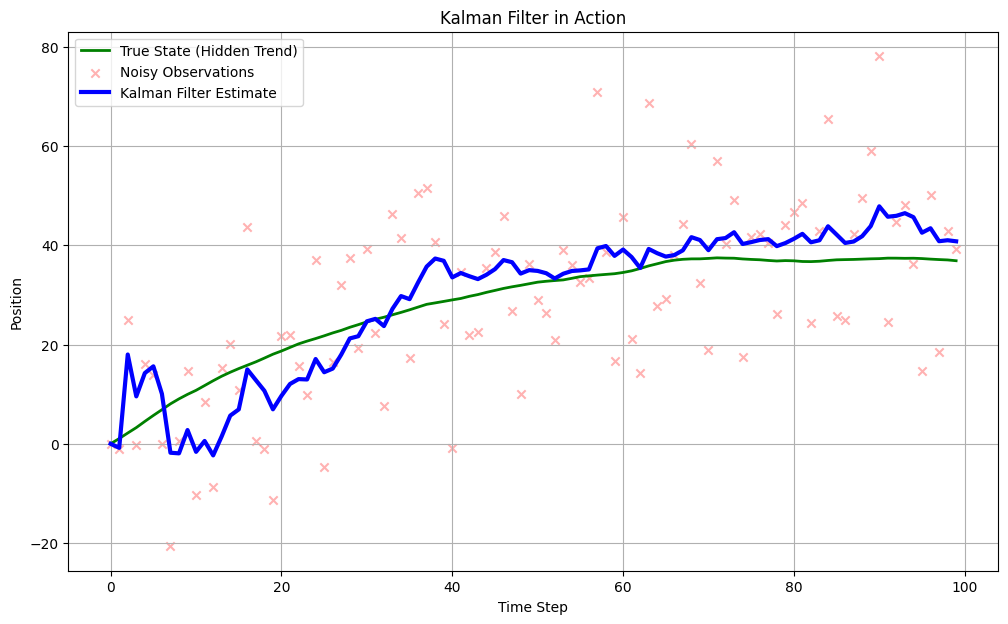

In [32]:
# 7. Visualise the Results
plt.figure(figsize=(12, 7))
plt.plot(true_position, label='True State (Hidden Trend)', color='green', linewidth=2)
plt.scatter(range(steps), measurements, label='Noisy Observations', color='red', marker='x', alpha=0.3)
plt.plot(kalman_estimates, label='Kalman Filter Estimate', color='blue', linewidth=3)

plt.title('Kalman Filter in Action')
plt.xlabel('Time Step')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()

\documentclass[9pt]{extarticle}
\usepackage[margin=0.55in]{geometry}
\usepackage{amsmath,amssymb,amsthm}
\usepackage{microtype}
\usepackage{parskip}
\setlength{\parskip}{2pt}

\newcommand{\RR}{\mathbb{R}}
\newcommand{\E}{\mathbb{E}}
\newcommand{\dd}{\mathrm{d}}
\newcommand{\Tr}{\operatorname{Tr}}
\newcommand{\dfdr}{\tfrac{\delta F}{\delta\rho}}

\begin{document}
\begin{center}\large\bfseries The effect of Adam on the DLE and DRLE underlying MoE--PVI\end{center}
\vspace{-0.4em}

\paragraph{Setup.} A predictively--oriented posterior carries a density $\rho$ on $\RR^d$ minimising the
entropy/KL--regularised free energy
\[
F(\rho)=U(\rho)+\tau\!\int\!\rho\log\frac{\rho}{\rho_0},\qquad
U(\rho)=\mathrm{MMD}^2(P_\rho,\hat P_n)\ \text{(or any predictive score loss)},
\]
with first variation $\dfdr=\Psi_\rho+\tau\log(\rho/\rho_0)+\tau$, where $\Psi_\rho:=\delta U/\delta\rho$ is the
data--fidelity potential. The $W_2$ gradient flow $\partial_t\rho=\nabla\!\cdot(\rho\nabla\dfdr)$ is the
mean--field Langevin PDE, whose particle (It\^o) realisation after Euler--Maruyama with step $h$ is the
\textbf{Discretised Langevin Equation}
\begin{equation}\tag{DLE}
\theta_{k+1}=\theta_k-h\big(\nabla\Psi_{\rho_k}(\theta_k)-\tau\nabla\log\rho_0(\theta_k)\big)+\sqrt{2\tau h}\,\xi_k,
\qquad \xi_k\sim\mathcal N(0,I).
\end{equation}
Writing $U_{\mathrm{eff}}=\Psi-\tau\log\rho_0$, the frozen--$\rho$ (or $N{=}1$) invariant law is $\pi\propto e^{-U_{\mathrm{eff}}/\tau}$.
Crucially the drift $-\nabla U_{\mathrm{eff}}$ and the noise amplitude $\sqrt{2\tau}$ are \emph{locked} by
fluctuation--dissipation: a diffusion $D$ with drift $b=-D\nabla(U_{\mathrm{eff}}/\tau)$ is invariant for
$e^{-U_{\mathrm{eff}}/\tau}$ only when the \emph{same} mobility $D$ multiplies both.

\paragraph{Adam on the DLE.} Adam replaces $g_k=\nabla U_{\mathrm{eff}}(\theta_k)$ by
$m_k=\beta_1 m_{k-1}+(1-\beta_1)g_k$, $v_k=\beta_2 v_{k-1}+(1-\beta_2)g_k^2$,
$\theta_{k+1}=\theta_k-\alpha\,\hat m_k\oslash(\sqrt{\hat v_k}+\varepsilon)$ ($+\sqrt{2\tau h}\,\xi_k$ if noise is injected).
In the quasi--static regime $\hat m_k\approx g_k$ this is a preconditioned step with diagonal SPD
$P_k=\operatorname{diag}\big((\sqrt{\hat v_k}+\varepsilon)^{-1}\big)$. Two distinct breakages follow.

\emph{(1) Uncompensated noise $\Rightarrow$ wrong stationary covariance.} The continuous analogue of
Adam{+}isotropic noise is $\dd\theta=-\alpha P_t\nabla U_{\mathrm{eff}}\,\dd t+\sqrt{2\tau h}\,\dd W$.
For a quadratic well $U_{\mathrm{eff}}=\tfrac12\theta^\top\Lambda\theta$ ($\Lambda=\operatorname{diag}\Lambda_a$),
the per--mode spring is $k_a=\alpha P_a\Lambda_a$ and the diffusion is $\tau h$, so the Ornstein--Uhlenbeck
stationary variance is $\sigma_a^2=\tau h/k_a$. At the Adam fixed point $v_a=\E[g_a^2]=\Lambda_a^2\sigma_a^2$,
hence $P_a\approx(\Lambda_a\sigma_a)^{-1}$, $k_a=\alpha/\sigma_a$, and
\begin{equation}
\boxed{\ \sigma_a^2\;\approx\;\Big(\tfrac{\tau h}{\alpha}\Big)^{2}\ \text{ for every }a\ }
\qquad\text{versus the correct Langevin}\qquad
\sigma_a^{2,\star}=\tau/\Lambda_a .
\end{equation}
Adam drives the posterior to an \emph{isotropic, curvature--blind} width fixed by the step/learning--rate
ratio $\tau h/\alpha$ --- each mode is mis--scaled by a factor $\propto\Lambda_a$ (sharp directions over--broadened, flat ones collapsed). This is the leading--order origin of the toy's wrong width
(empirically var $0.196$ vs.\ the true $0.568$).

\emph{(2) Missing It\^o correction.} Since $P_t$ depends on $\theta$ through the gradient history, the
law--consistent preconditioned Langevin requires the extra drift $\tau\nabla\!\cdot P$
(Girolami--Calderhead; Ma et al.). Adam omits it, adding an $O(\nabla P)$ bias toward regions where the
curvature--hence $v$--varies. Deterministic Adam ($\tau\!\to\!0$, no injected noise) contracts to
$\arg\min U_{\mathrm{eff}}$: a point mass / MAP estimate with \emph{no} posterior dispersion at all.

\paragraph{The DRLE.} The Wasserstein--Fisher--Rao (Hellinger--Kantorovich) gradient flow of the \emph{same}
$F$ augments transport$+$diffusion with a reaction (birth--death) term,
\[
\partial_t\rho=\underbrace{\nabla\!\cdot(\rho\nabla\dfdr)}_{W_2\ \text{transport}}
\;-\;\underbrace{\rho\big(\dfdr-\E_\rho[\dfdr]\big)}_{\text{Fisher--Rao reaction}},
\]
a gradient flow of $F$ in the WFR metric
$g_\rho(\phi,\phi)=\int\rho|\nabla\phi|^2+\int\rho(\phi-\!\int\!\phi\rho)^2$, whose two pieces share the
\emph{single} potential $\phi=\dfdr$. Its particle realisation --- the \textbf{Discretised Reaction Langevin
Equation} --- carries weights $w^i$:
\begin{equation}\tag{DRLE}
\theta^i_{k+1}=\theta^i_k-h\nabla U_{\mathrm{eff}}(\theta^i_k)+\sqrt{2\tau h}\,\xi^i_k,
\qquad
\log w^i_{k+1}=\log w^i_k-h\big(\beta^i_k-\bar\beta_k\big),\ \ \beta^i_k=\tfrac1\tau\dfdr(\theta^i_k),
\end{equation}
the weight ODE realised by periodic birth--death/resampling. Lu--Lu--Nolen and Lu--Slep\v{c}ev--Wang show the
reaction gives $F$ a Lyapunov decay $\tfrac{\dd}{\dd t}F=-\|\nabla_{\mathrm{WFR}}F\|^2$ whose rate is set by a
$\chi^2$/Poincar\'e constant and is \emph{independent of the inter--mode barrier}: it relocates mass across
modes without crossing, curing metastability.

\paragraph{Adam on the DRLE.} Three failures compound.
\emph{(a)} The transport block is a DLE, so Adam corrupts its invariant law exactly as above; the within--mode
law is no longer Gibbs at temperature $\tau$.
\emph{(b)} WFR is a gradient flow \emph{only} when transport and reaction use the same potential and metric.
Adam preconditions transport by $P_t$ but leaves the reaction rate $\beta^i\propto\dfdr$ untouched; the pair
is then not a WFR gradient flow of $F$ (nor of any $F$ under a single metric), so the identity
$\dot F=-\|\nabla_{\mathrm{WFR}}F\|^2$ and the barrier--independent rate are \emph{void}.
\emph{(c)} The reaction equilibrates weights toward $w^i\propto\rho_0(\theta^i)e^{-\Psi(\theta^i)/\tau}$, but
Adam's transport never realises that within--mode Gibbs shape, so birth--death reweights toward a target the
particle \emph{positions} do not represent --- the two dynamics fight rather than compose. With deterministic
Adam the diffusion vanishes, there is no entropy for the reaction to balance, and birth--death degenerates to
``keep the lowest--$U$ particle,'' collapsing the ensemble.

\paragraph{Takeaway.} Adam accelerates \emph{optimisation} and destroys \emph{sampling}; PrO needs sampling.
The correct accelerator is a Riemannian (Bures--Wasserstein) preconditioner $M$ that co--transforms drift and
noise, $\dd\theta=-M\nabla U\,\dd t+\tau(\nabla\!\cdot M)\,\dd t+\sqrt{2\tau M}\,\dd W$, and induces the matching
reaction metric --- not a coordinate--wise adaptive optimiser that preconditions the drift alone.
\end{document}